In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/model", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./models", exist_ok=True)
%matplotlib inline

In [2]:
stations_reference_df = pd.read_parquet("./data/processed/stations_reference.parquet")
train_moments_df = pd.read_parquet("./data/processed/train_moments_clean.parquet")
road_closures_df = pd.read_parquet("./data/processed/road_closures_clean.parquet")
timetable_df = pd.read_parquet("./data/processed/darwin_timetable_clean.parquet")
road_train_moments_df = pd.read_parquet("./data/processed/road_train_moments_dataset.parquet")
road_timetable_df = pd.read_parquet("./data/processed/road_timetable_dataset.parquet")

def print_df_summary(name, df):
    print(f"\n {name}")
    print(f"   Rows: {len(df):,}")
    print(f"   Columns: {len(df.columns):,}")
    print(f"   Column names: {list(df.columns)}")


print("=== Loaded Data Summary ===")

print_df_summary("Stations Reference", stations_reference_df)
print_df_summary("Train Moments", train_moments_df)
print_df_summary("Road Closures", road_closures_df)
print_df_summary("Darwin Timetable", timetable_df)
print_df_summary("Road–Train Moments Dataset", road_train_moments_df)
print_df_summary("Road–Timetable Dataset", road_timetable_df)

print("\n All datasets loaded successfully.")


=== Loaded Data Summary ===

 Stations Reference
   Rows: 2,594
   Columns: 8
   Column names: ['station', 'postcode', 'latitude', 'longitude', 'tlc', 'nlc', 'stanox', 'tiploc']

 Train Moments
   Rows: 39,091
   Columns: 22
   Column names: ['train_id', 'actual_timestamp', 'planned_timestamp', 'gbtt_timestamp', 'loc_stanox', 'next_stanox', 'event_type', 'planned_event_type', 'variation_status', 'timetable_variation', 'platform', 'route', 'direction', 'train_terminated', 'delay_monitoring_point', 'msg_timestamp', 'data_source', 'is_delayed', 'station_code', 'actual_hour', 'actual_dow', 'actual_date']

 Road Closures
   Rows: 352
   Columns: 20
   Column names: ['situation_id', 'record_id', 'start_time', 'end_time', 'validity_status', 'cause_type', 'source', 'road_name', 'lanes_closed', 'closure_lat', 'closure_lon', 'poslist', 'ingestion_time', 'closure_type', 'start_time_dt', 'end_time_dt', 'start_hour', 'start_dow', 'start_date', 'duration_hours']

 Darwin Timetable
   Rows: 1,898,719

In [3]:
road_timetable_df["planned_timestamp"] = (
    pd.to_datetime(road_timetable_df["planned_timestamp"])
    .astype("datetime64[ns]")
)

road_train_moments_df["planned_timestamp"] = (
    pd.to_datetime(road_train_moments_df["planned_timestamp"])
    .astype("datetime64[ns]")
)

print(road_timetable_df["planned_timestamp"].dtype)
print(road_train_moments_df["planned_timestamp"].dtype)

datetime64[ns]
datetime64[ns]


In [4]:
features = [
    "distance_in_km",
    "planned_time_diff",
    "closure_type",
    "event_type",
    "distance_time_interaction",
]

X = road_train_moments_df[features]
y = road_train_moments_df["delay"]

# Time-based split (80/20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} rows ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test:  {len(X_test):,} rows ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nTrain delay - mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"Test delay  - mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")

Train: 74,999 rows (80%)
Test:  18,750 rows (20%)

Train delay - mean: 1.206, std: 5.604
Test delay  - mean: 0.651, std: 4.352


C:\Users\patil\AppData\Local\Temp\ipykernel_22716\3839712708.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([y_train, y_test], labels=["Train", "Test"], patch_artist=True,


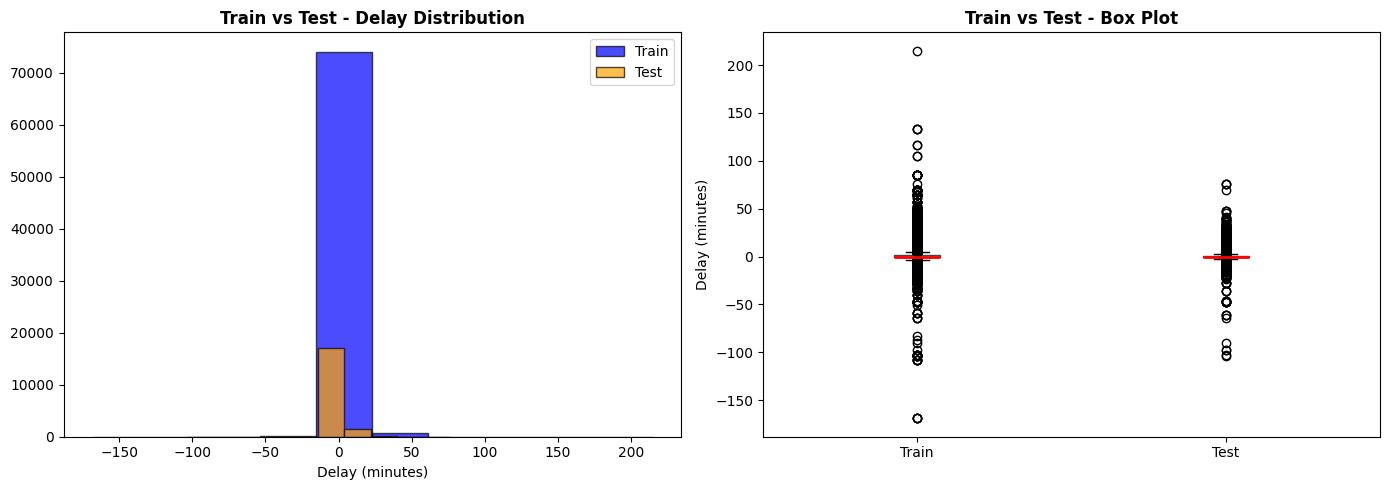

In [5]:
# Train/test distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=10, alpha=0.7, label="Train", color="blue", edgecolor="black")
axes[0].hist(y_test, bins=10, alpha=0.7, label="Test", color="orange", edgecolor="black")
axes[0].set_xlabel("Delay (minutes)")
axes[0].set_title("Train vs Test - Delay Distribution", fontweight="bold")
axes[0].legend()

axes[1].boxplot([y_train, y_test], labels=["Train", "Test"], patch_artist=True,
                boxprops=dict(facecolor="lightgreen", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Delay (minutes)")
axes[1].set_title("Train vs Test - Box Plot", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/model/train_test_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error, explained_variance_score,
    mean_absolute_percentage_error,
)
import time as timer

# Preprocessor
categorical_cols = ["closure_type", "event_type"]
numeric_cols = ["distance_in_km", "planned_time_diff", "distance_time_interaction"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", "passthrough", numeric_cols),
])

# Models
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42,
    ),
    "XGBoost_tuned": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1, random_state=42,
    ),
}

In [7]:
# Train and evaluate all models
results = []

for name, model_obj in models.items():
    pipeline = Pipeline([("prep", preprocessor), ("model", model_obj)])

    t0 = timer.time()

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    elapsed = timer.time() - t0

    print(f"Trained {name} in {elapsed:.2f}s")

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "MedianAE": median_absolute_error(y_test, y_pred),
        "MAPE": mean_absolute_percentage_error(y_test, y_pred),
        "ExplainedVar": explained_variance_score(y_test, y_pred),
        "pipeline": pipeline,
    })

results_df = pd.DataFrame(results)
results_df[["model", "MAE", "RMSE", "R2", "MedianAE", "MAPE", "ExplainedVar"]]

Trained Linear in 0.09s
Trained RandomForest in 60.89s
Trained GradientBoosting in 7.83s
Trained XGBoost in 0.56s
Trained XGBoost_tuned in 1.01s


,model,MAE,RMSE,R2,MedianAE,MAPE,ExplainedVar
0,Linear,2.181949,4.381474,-0.013572,1.525731,1.028447e+15,-0.000124
1,RandomForest,2.540634,4.749680,-0.191085,1.590000,1.311996e+15,-0.172324
2,GradientBoosting,2.204485,4.390773,-0.017879,1.548056,1.050602e+15,-0.002977
3,XGBoost,2.260489,4.439497,-0.040595,1.554500,1.066111e+15,-0.026215
4,XGBoost_tuned,2.220189,4.401604,-0.022907,1.540775,1.037636e+15,-0.008904


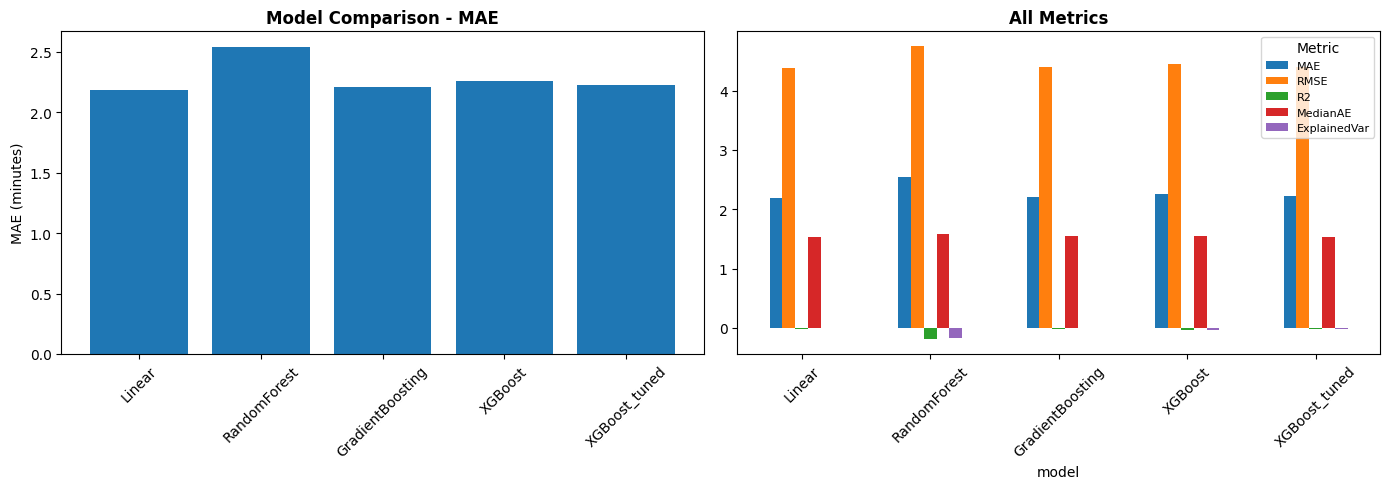

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_df["model"], results_df["MAE"])
axes[0].set_title("Model Comparison - MAE", fontweight="bold")
axes[0].set_ylabel("MAE (minutes)")
axes[0].tick_params(axis="x", rotation=45)

metrics = ["MAE", "RMSE", "R2", "MedianAE", "ExplainedVar"]
results_df.set_index("model")[metrics].plot(kind="bar", ax=axes[1])
axes[1].set_title("All Metrics", fontweight="bold")
axes[1].legend(title="Metric", fontsize=8)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figures/model/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Best model: Linear (MAE=2.182)


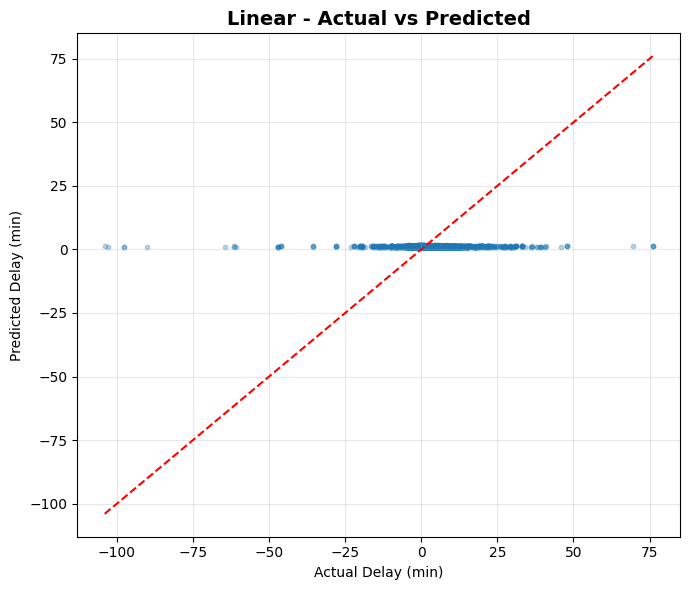

In [9]:
import joblib

best_row = results_df.sort_values("MAE").iloc[0]
best_model = best_row["pipeline"]
best_name = best_row["model"]
print(f"Best model: {best_name} (MAE={best_row['MAE']:.3f})")

# save it as a .pkl file
joblib.dump(best_model, "models/road_rail_model.pkl")

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Delay (min)")
plt.ylabel("Predicted Delay (min)")
plt.title(f"{best_name} - Actual vs Predicted", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/model/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


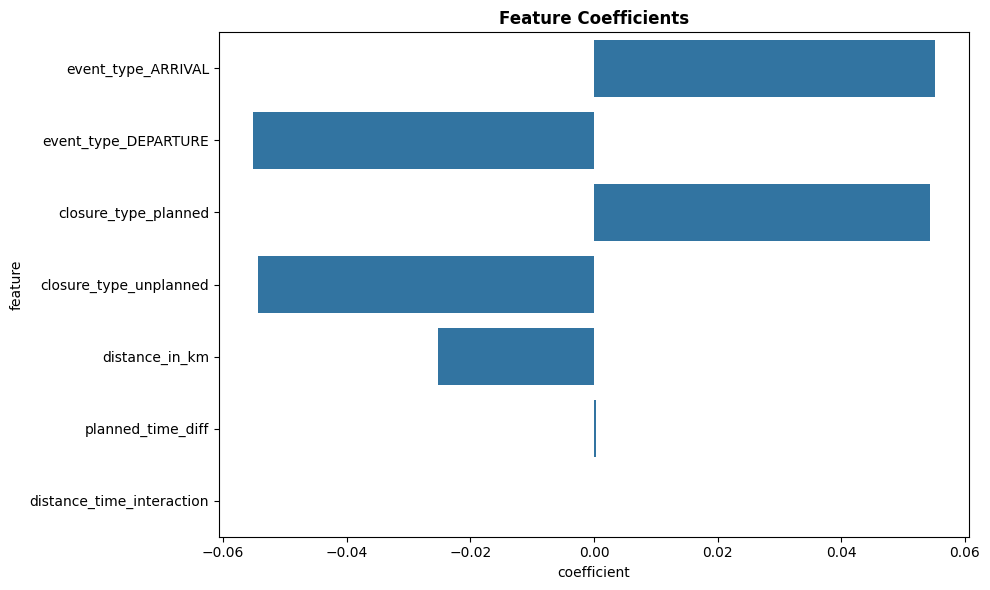

,feature,coefficient
2,event_type_ARRIVAL,0.055190
3,event_type_DEPARTURE,-0.055190
0,closure_type_planned,0.054325
1,closure_type_unplanned,-0.054325
4,distance_in_km,-0.025312
5,planned_time_diff,0.000338
6,distance_time_interaction,-0.000014


In [10]:
# Feature importance / coefficients
inner_model = best_model.named_steps["model"]
ohe = best_model.named_steps["prep"].named_transformers_["cat"]
feature_names = list(ohe.get_feature_names_out(categorical_cols)) + numeric_cols

if hasattr(inner_model, "feature_importances_"):
    imp_df = pd.DataFrame({"feature": feature_names, "importance": inner_model.feature_importances_})
    imp_df = imp_df.sort_values("importance", ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="importance", y="feature")
    plt.title("Feature Importance", fontweight="bold")
elif hasattr(inner_model, "coef_"):
    imp_df = pd.DataFrame({"feature": feature_names, "coefficient": inner_model.coef_})
    imp_df = imp_df.sort_values("coefficient", key=abs, ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp_df, x="coefficient", y="feature")
    plt.title("Feature Coefficients", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/model/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
display(imp_df)

In [11]:
X_future = road_timetable_df[features]
road_timetable_df["predicted_delay"] = best_model.predict(X_future)

filtered_columns =[
    "closure_type", "station_name", "distance_in_km",
    "closure_start_time", "planned_timestamp", "planned_time_diff", "predicted_delay",]
print(f"Total filtered timetable: {len(road_timetable_df):,} rows")
road_timetable_df[filtered_columns].head(10)

Total filtered timetable: 2,863,334 rows


,closure_type,station_name,distance_in_km,closure_start_time,planned_timestamp,planned_time_diff,predicted_delay
0,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 20:00:00,60.0,1.265914
1,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 12:24:00,-396.0,1.198715
2,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 11:02:30,-477.5,1.196569
3,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 12:03:00,-417.0,1.253352
4,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 15:02:30,-237.5,1.202889
5,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 17:03:00,-117.0,1.261253
6,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 18:00:00,-60.0,1.262754
7,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 07:21:30,-698.5,1.245939
8,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 08:24:30,-635.5,1.247598
9,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 06:56:00,-724.0,1.245267


In [12]:
planned_df = road_timetable_df[road_timetable_df["closure_type"] == "planned"]
unplanned_df = road_timetable_df[road_timetable_df["closure_type"] == "unplanned"]

print(f"Planned closures: {len(planned_df):,} rows")
display(planned_df[filtered_columns].head())

print(f"Unplanned closures: {len(unplanned_df):,} rows")
display(unplanned_df[filtered_columns].head())


Planned closures: 826,555 rows


,closure_type,station_name,distance_in_km,closure_start_time,planned_timestamp,planned_time_diff,predicted_delay
0,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 20:00:00,60.0,1.265914
1,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 12:24:00,-396.0,1.198715
2,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 11:02:30,-477.5,1.196569
3,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 12:03:00,-417.0,1.253352
4,planned,Dullingham,21.561992,2026-04-11 19:00:00,2026-04-11 15:02:30,-237.5,1.202889


Unplanned closures: 2,036,779 rows


,closure_type,station_name,distance_in_km,closure_start_time,planned_timestamp,planned_time_diff,predicted_delay
826555,unplanned,Acton Central,20.4733,2026-04-10 16:27:32,2026-04-10 06:09:00,-618.533333,1.157212
826556,unplanned,Acton Central,20.4733,2026-04-10 16:27:32,2026-04-10 06:31:00,-596.533333,1.158138
826557,unplanned,Acton Central,20.4733,2026-04-10 16:27:32,2026-04-10 06:43:00,-584.533333,1.158642
826558,unplanned,Acton Central,20.4733,2026-04-10 16:27:32,2026-04-10 06:05:30,-622.033333,1.157064
826559,unplanned,Acton Central,20.4733,2026-04-10 16:27:32,2026-04-10 22:16:30,348.966667,1.197925


In [13]:
# Create 1‑minute bins from 0 to 60
bins = list(range(0, 62, 1))   # 0,1,2,3,...60,61
labels = [f"{i}-{i+1} mins" for i in range(0, 61)]


road_timetable_df["delay_bucket"] = pd.cut(
    road_timetable_df["predicted_delay"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)


In [14]:
bucket_summary = (
    road_timetable_df
    .groupby(["closure_type", "delay_bucket"])
    .size()
    .reset_index(name="count")
    .sort_values(["closure_type", "delay_bucket"])
)

planned_summary = bucket_summary[bucket_summary["closure_type"] == "planned"]
unplanned_summary = bucket_summary[bucket_summary["closure_type"] == "unplanned"]

display(planned_summary)
display(unplanned_summary)


,closure_type,delay_bucket,count
0,planned,1-2 mins,826555


,closure_type,delay_bucket,count
1,unplanned,0-1 mins,19825
2,unplanned,1-2 mins,2016954


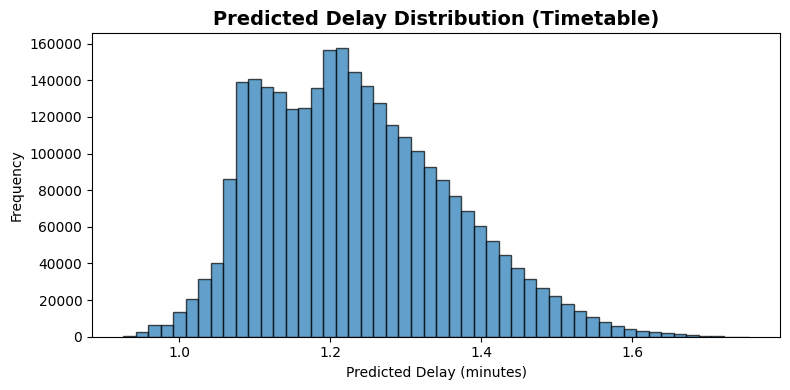

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(road_timetable_df["predicted_delay"], bins=50, edgecolor="black", alpha=0.7)
plt.title("Predicted Delay Distribution (Timetable)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Delay (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("figures/model/predicted_delay_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# Match timetable predictions to actual train movements
comparison_df = pd.merge_asof(
    road_timetable_df.sort_values("planned_timestamp"),
    road_train_moments_df.sort_values("planned_timestamp"),
    on="planned_timestamp",
    by="station_name",
    direction="nearest",
    tolerance=pd.Timedelta("20min"),
)

match_rate = comparison_df["actual_timestamp"].notna().mean()
print(f"Total timetable rows: {len(road_timetable_df):,}")
print(f"Matched rows: {comparison_df['actual_timestamp'].notna().sum():,}")
print(f"Match rate: {match_rate:.2%}")

Total timetable rows: 2,863,334
Matched rows: 573,517
Match rate: 20.03%


Aggregated station-level MAE: 1.685 minutes


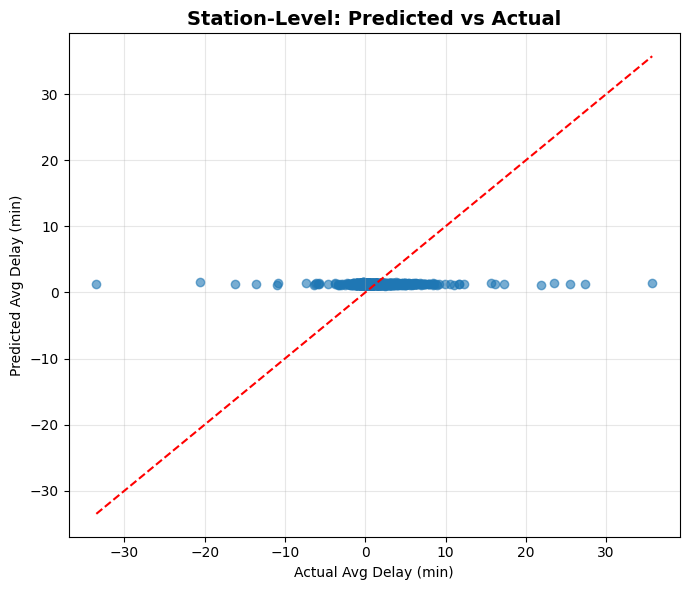

,predicted_delay,actual_delay
station_name,,
Abbey Wood,1.283310,0.536585
Accrington,1.249300,0.160000
Acle,1.362530,-0.800000
Acocks Green,1.328537,0.500000
Acton Bridge (Cheshire),1.257512,5.188889
...,...,...
Wythall,1.392131,0.750000
Yalding,1.316318,-0.750000
Yardley Wood,1.231766,0.071429


In [17]:
# Station-level aggregated comparison
road_train_moments_df["actual_delay"] = road_train_moments_df["delay"]

pred_summary = road_timetable_df.groupby("station_name")["predicted_delay"].mean()
actual_summary = road_train_moments_df.groupby("station_name")["actual_delay"].mean()

comparison = pd.concat([pred_summary, actual_summary], axis=1).dropna()

from sklearn.metrics import mean_absolute_error
agg_mae = mean_absolute_error(comparison["actual_delay"], comparison["predicted_delay"])
print(f"Aggregated station-level MAE: {agg_mae:.3f} minutes")

plt.figure(figsize=(7, 6))
plt.scatter(comparison["actual_delay"], comparison["predicted_delay"], alpha=0.6)
mn, mx = comparison.min().min(), comparison.max().max()
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("Actual Avg Delay (min)")
plt.ylabel("Predicted Avg Delay (min)")
plt.title("Station-Level: Predicted vs Actual", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/model/station_level_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

display(comparison)